# **0. Import dan Notes**

## 0.1. Penjelasan Library yang Digunakan

| No | Library | Fungsi |
|----|---------|--------|
| 1 | `pandas` | Membaca dan mengolah data dalam bentuk DataFrame |
| 2 | `matplotlib.pyplot` | Membuat visualisasi data seperti grafik |
| 3 | `seaborn` | Membuat plot statistik yang lebih menarik |
| 4 | `re` | Membersihkan teks menggunakan regular expression |
| 5 | `nltk.tokenize` | Memecah kalimat menjadi kata per kata (tokenisasi) |
| 6 | `requests` | Mengambil file kamus dari internet |
| 7 | `io.BytesIO`| Membaca file excel dari hasil download |
| 8 | `wordcloud` | Membuat visualisasi kata yang paling sering muncul |
| 9 | `nltk.corpus` | Menyediakan daftar stopword bahasa Indonesia |

## 0.2. Alur Preprocessing dalam Kode Ini

| Step | Nama Step | Keterangan |
|------|-----------|-------------|
| 1 | Data Loading | Membaca dataset komentar YouTube |
| 1.2 | EDA Statistik | Melihat info dan deskripsi data |
| 1.3 | EDA Time Series | Melihat sebaran komentar per bulan |
| 2.1 | Drop Null dan Duplicate | Menghapus data kosong dan data ganda |
| 2.2 | Char Cleaning dan Case Folding | Membersihkan URL, username, emoji, simbol, angka, dan mengubah ke huruf kecil |
| 2.3.1 | Normalisasi Kata Baku (Kamus Umum) | Mengubah kata tidak baku dari kamus online |
| 2.3.2 | Normalisasi Kata Baku (Kamus Tambahan) | Mengubah kata tidak baku berdasarkan hasil WordCloud |
| 2.4.1 | Stopword Removal (NLTK) | Menghapus stopword bawaan NLTK |
| 2.4.2 | Stopword Removal (Tambahan Manual) | Menghapus stopword tambahan dari hasil WordCloud |
| 3 | Labeling | Label setiap comment dengan metode lexicon-based labeling |
| 4 | Menyimpan Data | Menyimpan dua versi dataset hasil preprocessing |

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.tokenize import word_tokenize
import requests
from io import BytesIO
from wordcloud import WordCloud
from nltk.corpus import stopwords

# **1. Data Loading dan EDA**

# 1.1. Data Loading

In [50]:
data_load = pd.read_csv('raw_dataset.csv')
data_load['published_at'] = pd.to_datetime(data_load['published_at'])

data_load.head()

,author,comment,published_at
0,@yukiyaarashi4010,Wah yg belum nonton trauma code korea tonton d...,2026-04-17 02:45:52+00:00
1,@FeriCakra-l3t,"oohh aku baru tau, ternyata ada vaksin buat tyfus",2026-04-15 13:46:22+00:00
2,@sufoniatunsufoniatun21,ga ada yg seruuu dokkk org berdarah itu😭,2026-04-13 13:02:44+00:00
3,@sea9856,dokter itu kaya gini loh.. woi dokter2 di indo...,2026-04-13 09:35:59+00:00
4,@suryadinata2545,Pengen dengar cerita2 igd nya .. meski takut2 ...,2026-04-13 00:41:36+00:00


# 1.2. EDA dari Statistik Dataset

In [51]:
data_load.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   author        15000 non-null  object             
 1   comment       15000 non-null  object             
 2   published_at  15000 non-null  datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), object(2)
memory usage: 351.7+ KB


In [52]:
data_load.describe().round(2).head(2)

,author,comment,published_at
count,15000,15000,15000
unique,11109,11642,NaN


# 1.3. EDA dari `published_at` dengan Histogram Plot

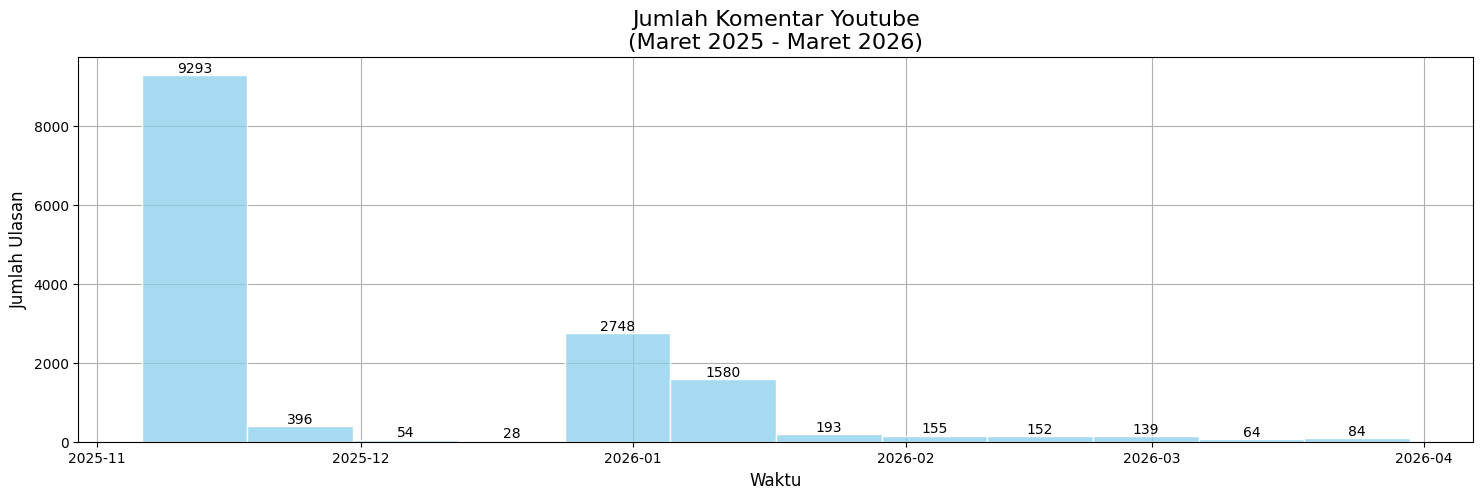

In [53]:
data_plot = data_load.copy()
data_plot['published_at'] = pd.to_datetime(data_plot['published_at'])

mask = data_plot['published_at'].between('2025-03-01', '2026-03-31')
data_plot_filtered = data_plot.loc[mask].copy()

plt.figure(figsize=(18, 5))

sns.histplot(data=data_plot_filtered, x='published_at', bins=12, color='skyblue', edgecolor='white', zorder=2)

for patch in plt.gca().patches:
    height = patch.get_height()
    if height > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            height,
            f'{int(height)}',
            ha='center',
            va='bottom'
        )

plt.title("Jumlah Komentar Youtube\n(Maret 2025 - Maret 2026)", fontsize=16)
plt.xlabel("Waktu", fontsize=12)
plt.ylabel("Jumlah Ulasan", fontsize=12)

plt.grid(True)
plt.show()

# **2. Data Cleaning dan Preprocessing**

# 2.1. Drop Null dan Duplicate

In [54]:
df = pd.DataFrame(data_load['comment'])

In [55]:
print(f"Sebelum Drop NA: {df.isnull().sum().values}")

df.dropna(inplace=True)

print(f"Setelah Drop NA: {df.isnull().sum().values}")

Sebelum Drop NA: [0]
Setelah Drop NA: [0]


In [56]:
print(f"Sebelum Drop NA: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(f"Setelah Drop NA: {df.duplicated().sum()}")

Sebelum Drop NA: 3358
Setelah Drop NA: 0


# 2.2. Char Cleaning (Urls, Username, Emoji, Symbol, Number) dan Case Folding

In [57]:
def remove_urls(comment):
    url = re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'', comment)

def remove_usernames(comment):
    return re.sub(r'@\w+', '', comment)

def remove_htmls(comment):
    html = re.compile(r'<.*?>')
    return html.sub(r'', comment)

def remove_emojis(comment):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F700-\U0001F77F"
        u"\U0001F780-\U0001F7FF"
        u"\U0001F800-\U0001F8FF"
        u"\U0001F900-\U0001F9FF"
        u"\U0001FA00-\U0001FA6F"
        u"\U0001FA70-\U0001FAFF"
        u"\U0001F004-\U0001F0CF"
        u"\U0001F1E0-\U0001F1FF"
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', comment)

def remove_symbols(comment):
    return re.sub(r'[^a-zA-Z0-9\s]', '', comment)

def remove_numbers(comment):
    return re.sub(r'\d', '', comment)

def case_folding(comment):
    return comment.lower()

df['char_cleaning'] = df['comment'].apply(lambda x: remove_urls(x))
df['char_cleaning'] = df['char_cleaning'].apply(lambda x: remove_usernames(x))
df['char_cleaning'] = df['char_cleaning'].apply(lambda x: remove_htmls(x))
df['char_cleaning'] = df['char_cleaning'].apply(lambda x: remove_emojis(x))
df['char_cleaning'] = df['char_cleaning'].apply(lambda x: remove_symbols(x))
df['char_cleaning'] = df['char_cleaning'].apply(lambda x: remove_numbers(x))
df['char_cleaning'] = df['char_cleaning'].apply(lambda x: case_folding(x))

df.head(5)

,comment,char_cleaning
0,Wah yg belum nonton trauma code korea tonton d...,wah yg belum nonton trauma code korea tonton d...
1,"oohh aku baru tau, ternyata ada vaksin buat tyfus",oohh aku baru tau ternyata ada vaksin buat tyfus
2,ga ada yg seruuu dokkk org berdarah itu😭,ga ada yg seruuu dokkk org berdarah itu
3,dokter itu kaya gini loh.. woi dokter2 di indo...,dokter itu kaya gini loh woi dokter di indonesia
4,Pengen dengar cerita2 igd nya .. meski takut2 ...,pengen dengar cerita igd nya meski takut lan...


# 2.3.1. Normalisasi Kata Baku dari Kamus `https://github.com/analysisdatasentiment`

In [58]:
url = "https://github.com/analysisdatasentiment/kamus_kata_baku/raw/main/kamuskatabaku.xlsx"

response = requests.get(url)
file_excel = BytesIO(response.content)
kamus_kata_baku = pd.read_excel(file_excel)

taboo_dictionary = dict(zip(kamus_kata_baku['tidak_baku'], kamus_kata_baku['kata_baku']))

def replace_kata_baku(comment, taboo_dictionary):
    words = word_tokenize(comment.lower())
    result = [taboo_dictionary[word.lower()] if word in taboo_dictionary else word for word in words]
    return " ".join(result)

df['kata_baku'] = df['char_cleaning'].apply(lambda x: replace_kata_baku(x, taboo_dictionary))

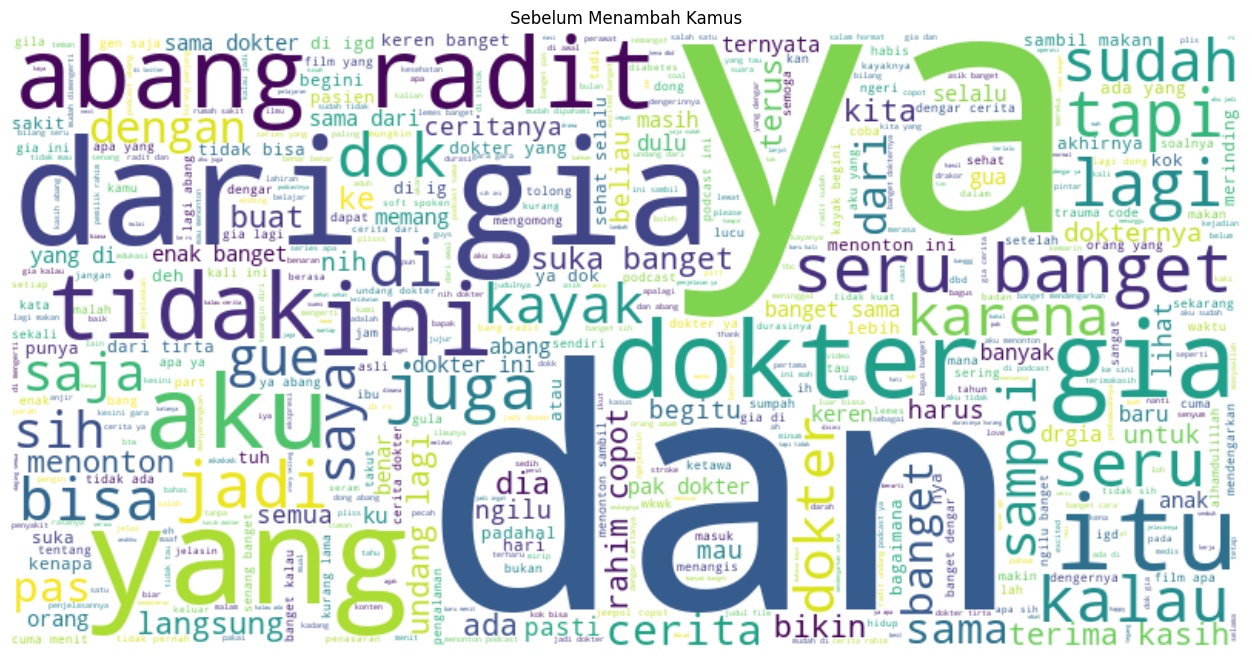

In [59]:
full_comment_before = " ".join(df['kata_baku'].astype(str).tolist())

wordcloud = WordCloud(
    background_color='white',
    max_words=500,
    width=800,
    height=400
).generate(full_comment_before)

plt.figure(figsize=(16, 8))
plt.title("Sebelum Menambah Kamus")
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.show()

# 2.3.2. Normalisasi dari Kamus Tambahan Berdasarkan Analisis WordCloud

In [60]:
additional_entries = {
    "bgt": "banget",
    "dokter": "dok",
    "dokternya": "dok",
    "ngakak": "tertawa",
    "mengakak": "tertawa",
    "pengin": "pingin",
    "keren": "kagum",
    "menonton": "menyaksikan",
    "daging": "bermanfaat",
    "kesehatan": "sehat",
    "bikin": "membuat",
    "orang": "manusia",
    "kayak": "seperti",
    "kali": "mungkin",
    "ya": "iyak",
    "tuh": "itu"
}

df['kata_baku'] = df['kata_baku'].apply(lambda x: replace_kata_baku(x, additional_entries))

df.head()

,comment,char_cleaning,kata_baku
0,Wah yg belum nonton trauma code korea tonton d...,wah yg belum nonton trauma code korea tonton d...,wah yang belum menyaksikan trauma code korea t...
1,"oohh aku baru tau, ternyata ada vaksin buat tyfus",oohh aku baru tau ternyata ada vaksin buat tyfus,oohh aku baru tau ternyata ada vaksin buat tyfus
2,ga ada yg seruuu dokkk org berdarah itu😭,ga ada yg seruuu dokkk org berdarah itu,tidak ada yang seru dokkk manusia berdarah itu
3,dokter itu kaya gini loh.. woi dokter2 di indo...,dokter itu kaya gini loh woi dokter di indonesia,dok itu seperti begini loh woi dok di indonesia
4,Pengen dengar cerita2 igd nya .. meski takut2 ...,pengen dengar cerita igd nya meski takut lan...,pingin dengar cerita igd iyak meski takut lanj...


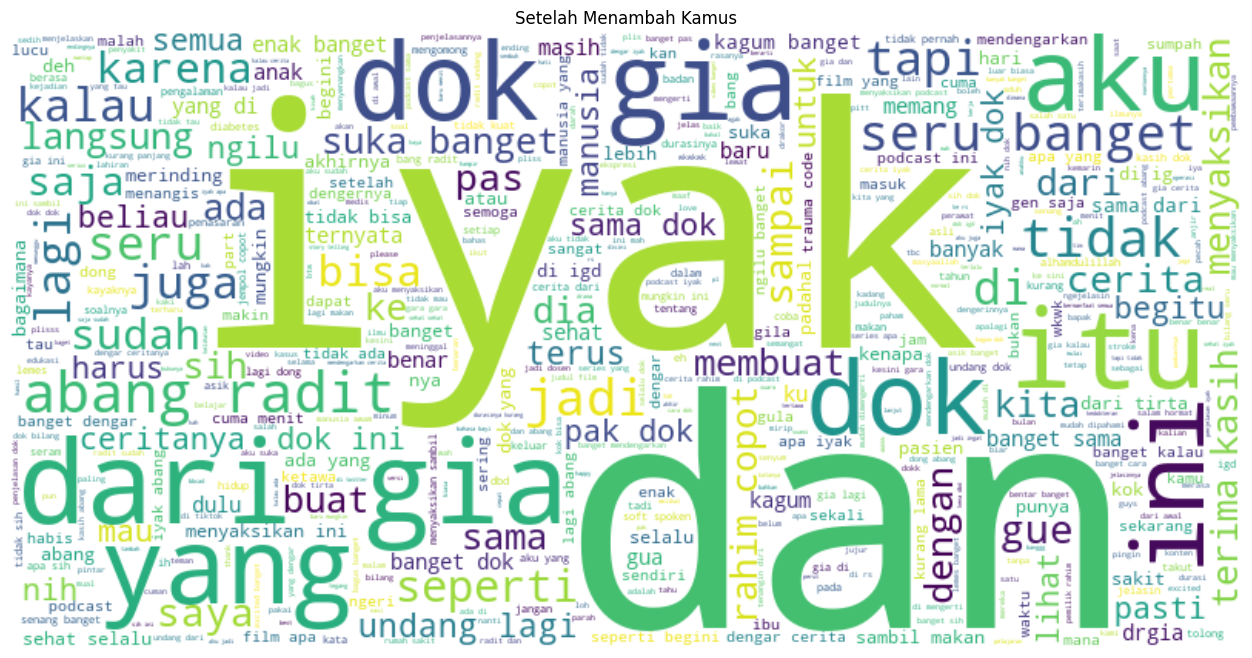

In [61]:
full_comment_after = " ".join(df['kata_baku'].astype(str).tolist())

wordcloud = WordCloud(
    background_color='white',
    max_words=500,
    width=800,
    height=400
).generate(full_comment_after)

plt.figure(figsize=(16, 8))
plt.title("Setelah Menambah Kamus")
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.show()

# 2.4.1. Stopword Removal dengan NLTK

In [62]:
def remove_stopword(comment, stopword):
    words = word_tokenize(comment)
    
    result = [word for word in words if word not in stopword]
    return " ".join(result)

stopword = stopwords.words('indonesian')
df['remove_stopword'] = df['kata_baku'].apply(lambda x: remove_stopword(x, stopword))

df.head()

,comment,char_cleaning,kata_baku,remove_stopword
0,Wah yg belum nonton trauma code korea tonton d...,wah yg belum nonton trauma code korea tonton d...,wah yang belum menyaksikan trauma code korea t...,menyaksikan trauma code korea tonton deh seru ...
1,"oohh aku baru tau, ternyata ada vaksin buat tyfus",oohh aku baru tau ternyata ada vaksin buat tyfus,oohh aku baru tau ternyata ada vaksin buat tyfus,oohh tau vaksin tyfus
2,ga ada yg seruuu dokkk org berdarah itu😭,ga ada yg seruuu dokkk org berdarah itu,tidak ada yang seru dokkk manusia berdarah itu,seru dokkk manusia berdarah
3,dokter itu kaya gini loh.. woi dokter2 di indo...,dokter itu kaya gini loh woi dokter di indonesia,dok itu seperti begini loh woi dok di indonesia,dok loh woi dok indonesia
4,Pengen dengar cerita2 igd nya .. meski takut2 ...,pengen dengar cerita igd nya meski takut lan...,pingin dengar cerita igd iyak meski takut lanj...,pingin dengar cerita igd iyak takut dok podcas...


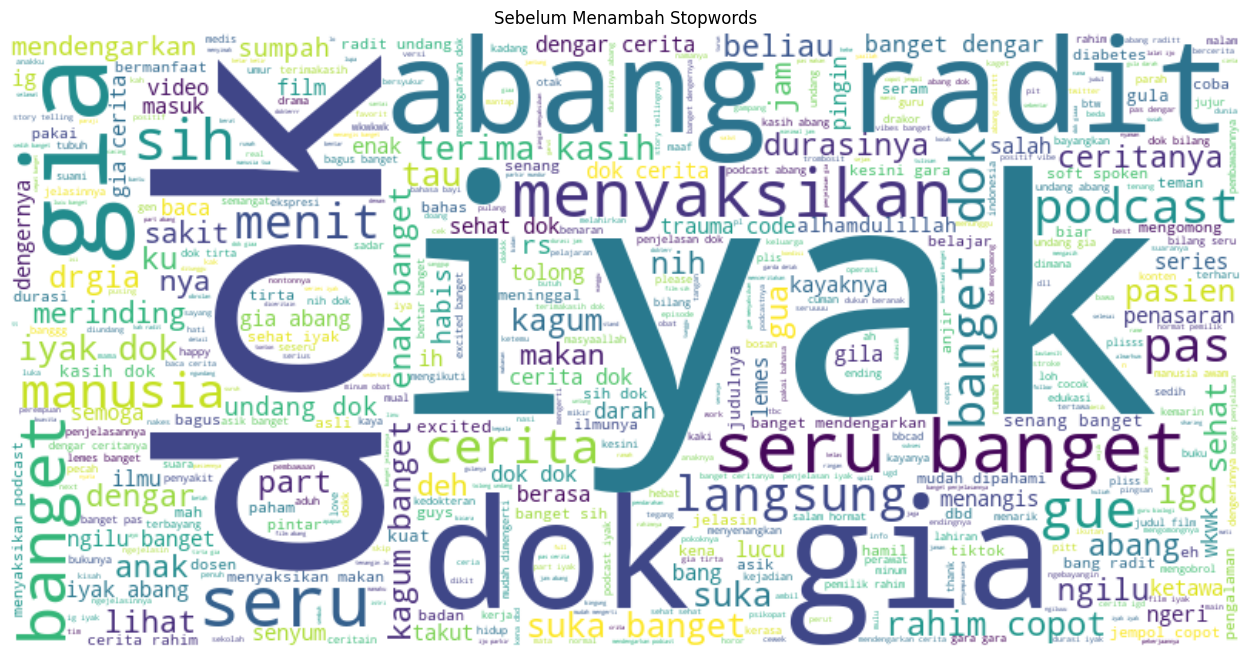

In [63]:
full_comment_before = " ".join(df['remove_stopword'].astype(str).tolist())

wordcloud = WordCloud(
    background_color='white',
    max_words=500,
    width=800,
    height=400
).generate(full_comment_before)

plt.figure(figsize=(16, 8))
plt.title("Sebelum Menambah Stopwords")
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.show()

# 2.4.2. Stopword Removal dengan List Tambahan dari Analisis WordCloud

In [64]:
additional_stopword = ['gia', 'abang', 'radit', 'podcast', 'sih', 'gue', 'mendengarkan', 'menit', 'igd', 'film', 
                       'nih', 'part', 'jam', 'durasinya', 'ku', 'the', 'bilang', 'beliau', 'tirta', 'drgia', 'bang', 
                       'ig', 'series', 'pasien', 'dengernya', 'kesini', 'rs', 'tiktok', 'nya', 'deh', 'durasi', 
                       'gula', 'dbd', 'penjelasannya', 'mengomong', 'pakai', 'semoga', 'video', 'code']

df['remove_stopword'] = df['kata_baku'].apply(lambda x: remove_stopword(x, additional_stopword))

df.head()

,comment,char_cleaning,kata_baku,remove_stopword
0,Wah yg belum nonton trauma code korea tonton d...,wah yg belum nonton trauma code korea tonton d...,wah yang belum menyaksikan trauma code korea t...,wah yang belum menyaksikan trauma korea tonton...
1,"oohh aku baru tau, ternyata ada vaksin buat tyfus",oohh aku baru tau ternyata ada vaksin buat tyfus,oohh aku baru tau ternyata ada vaksin buat tyfus,oohh aku baru tau ternyata ada vaksin buat tyfus
2,ga ada yg seruuu dokkk org berdarah itu😭,ga ada yg seruuu dokkk org berdarah itu,tidak ada yang seru dokkk manusia berdarah itu,tidak ada yang seru dokkk manusia berdarah itu
3,dokter itu kaya gini loh.. woi dokter2 di indo...,dokter itu kaya gini loh woi dokter di indonesia,dok itu seperti begini loh woi dok di indonesia,dok itu seperti begini loh woi dok di indonesia
4,Pengen dengar cerita2 igd nya .. meski takut2 ...,pengen dengar cerita igd nya meski takut lan...,pingin dengar cerita igd iyak meski takut lanj...,pingin dengar cerita iyak meski takut lanjut d...


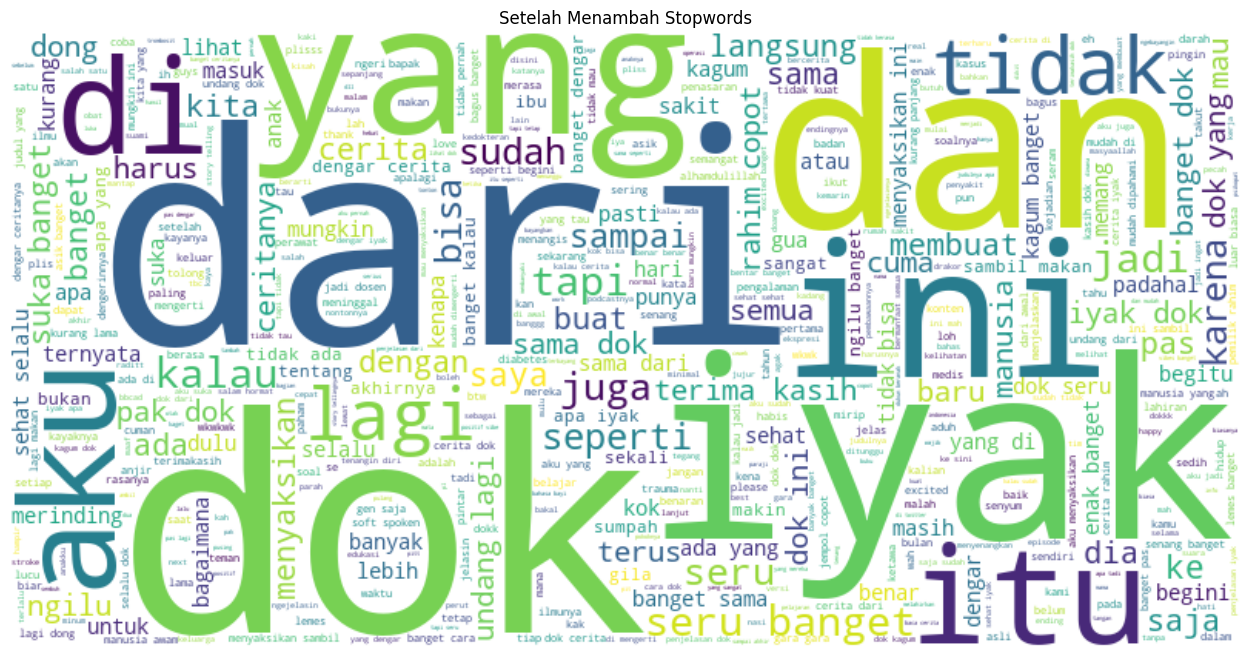

In [65]:
full_comment_after = " ".join(df['remove_stopword'].astype(str).tolist())

wordcloud = WordCloud(
    background_color='white',
    max_words=500,
    width=800,
    height=400
).generate(full_comment_after)

plt.figure(figsize=(16, 8))
plt.title("Setelah Menambah Stopwords")
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.show()

# **3. Labeling menggunakan Lexicon Based**

In [66]:
data = pd.DataFrame(df['remove_stopword'])
data.rename(columns={'remove_stopword': 'comment'}, inplace=True)
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)

data.head()

,comment
0,wah yang belum menyaksikan trauma korea tonton...
1,oohh aku baru tau ternyata ada vaksin buat tyfus
2,tidak ada yang seru dokkk manusia berdarah itu
3,dok itu seperti begini loh woi dok di indonesia
4,pingin dengar cerita iyak meski takut lanjut d...


In [67]:
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

In [68]:
def determine_sentiment(text):
    token = word_tokenize(text)
    positive_count = sum(1 for word in token if word in positive_lexicon)
    negative_count = sum(1 for word in token if word in negative_lexicon)
    sentiment_score = positive_count - negative_count
    
    if sentiment_score < 0:
        sentiment = 'negative'
    elif sentiment_score > 0:
        sentiment = 'positive'
    else:
        sentiment = 'neutral'
    
    return sentiment_score, sentiment

data[['score', 'sentiment']] = data['comment'].apply(lambda x: pd.Series(determine_sentiment(x)))
data.head(20)

,comment,score,sentiment
0,wah yang belum menyaksikan trauma korea tonton...,0,neutral
1,oohh aku baru tau ternyata ada vaksin buat tyfus,0,neutral
2,tidak ada yang seru dokkk manusia berdarah itu,-1,negative
3,dok itu seperti begini loh woi dok di indonesia,-1,negative
4,pingin dengar cerita iyak meski takut lanjut d...,0,neutral
5,masih bisa cerita cerita sambil ketawa,1,positive
6,lah sama seperti gilbhas afgan raisa dan enzy,0,neutral
7,membuat dokk,1,positive
8,apa guys yang dimention sama dari,-1,negative
9,baru berani menyaksikan ini menyesal euy pegel...,1,positive


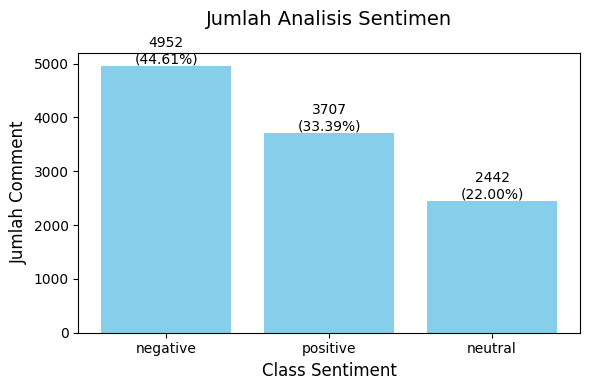

In [69]:
sentiment_count = data['sentiment'].value_counts()
total = len(data['sentiment'])

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(sentiment_count.index, sentiment_count.values, color='skyblue')

ax.set_title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
ax.set_xlabel('Class Sentiment', fontsize=12)
ax.set_ylabel('Jumlah Comment', fontsize=12)

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.5, f'{count}\n({percentage})', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# **4. Menyimpan Data Hasil Preprocess dan Labeling**

In [70]:
data.to_csv("labeled_dataset.csv", index=False, encoding='utf-8')